# RFM Customer Segmentation

## Customer Intelligence Analytics

This notebook segments customers according to their purchasing behavior using
RFM analysis:

- **Recency:** How recently did the customer purchase?
- **Frequency:** How often does the customer purchase?
- **Monetary:** How much has the customer spent?

The resulting segments will support retention targeting, customer-value
analysis, churn modeling, and future machine-learning segmentation.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")


PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent


CUSTOMER_SALES_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "customer_sales.parquet"
)

OUTPUT_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "rfm_customer_segments.parquet"
)

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


print(f"Project root: {PROJECT_ROOT}")
print(f"Input:        {CUSTOMER_SALES_PATH}")

Project root: c:\Users\omary\Documents\VS Code\customer-intelligence-analytics
Input:        c:\Users\omary\Documents\VS Code\customer-intelligence-analytics\data\processed\customer_sales.parquet


In [2]:
customer_sales = pd.read_parquet(
    CUSTOMER_SALES_PATH
)


customer_sales["invoice_key"] = (
    customer_sales["source_period"].astype("string")
    + "::"
    + customer_sales["invoice"].astype("string")
)


print(f"Sales rows:       {len(customer_sales):,}")
print(
    f"Customers:        "
    f"{customer_sales['customer_id'].nunique():,}"
)
print(
    f"Sales invoices:   "
    f"{customer_sales['invoice_key'].nunique():,}"
)
print(
    f"Revenue:          "
    f"{customer_sales['line_amount'].sum():,.2f}"
)
print(
    f"Date range:       "
    f"{customer_sales['invoice_date'].min()} "
    f"→ {customer_sales['invoice_date'].max()}"
)

Sales rows:       793,609
Customers:        5,878
Sales invoices:   37,745
Revenue:          17,685,460.64
Date range:       2009-12-01 07:45:00 → 2011-12-09 12:50:00


In [3]:
analysis_date = (
    customer_sales["invoice_date"].max()
    + pd.Timedelta(days=1)
)


print(f"RFM analysis date: {analysis_date}")

RFM analysis date: 2011-12-10 12:50:00


In [4]:
rfm = (
    customer_sales
    .groupby(
        "customer_id",
        observed=True,
    )
    .agg(
        first_purchase=("invoice_date", "min"),
        last_purchase=("invoice_date", "max"),
        frequency=("invoice_key", "nunique"),
        monetary=("line_amount", "sum"),
        total_units=("quantity", "sum"),
        unique_products=("stock_code", "nunique"),
    )
    .reset_index()
)


rfm["recency"] = (
    analysis_date
    - rfm["last_purchase"]
).dt.days


rfm["tenure_days"] = (
    rfm["last_purchase"]
    - rfm["first_purchase"]
).dt.days


rfm["average_order_value"] = (
    rfm["monetary"]
    / rfm["frequency"]
)


rfm.head()

,customer_id,first_purchase,last_purchase,frequency,monetary,total_units,unique_products,recency,tenure_days,average_order_value
0,12346,2009-12-14 08:34:00,2011-01-18 10:01:00,12,"77,556.46",74285,27,326,400,"6,463.04"
1,12347,2010-10-31 14:20:00,2011-12-07 15:52:00,9,"5,633.32",3286,126,2,402,625.92
2,12348,2010-09-27 14:59:00,2011-09-25 13:13:00,5,"2,019.40",2714,25,75,362,403.88
3,12349,2010-04-29 13:20:00,2011-11-21 09:51:00,4,"4,428.69",1624,138,19,570,"1,107.17"
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,197,17,310,0,334.40


In [5]:
assert len(rfm) == customer_sales["customer_id"].nunique()

assert (rfm["recency"] >= 0).all()
assert (rfm["frequency"] >= 1).all()
assert (rfm["monetary"] > 0).all()

assert np.isclose(
    rfm["monetary"].sum(),
    customer_sales["line_amount"].sum(),
)


print("RFM dataset validation passed successfully.")
print(f"Customers: {len(rfm):,}")

RFM dataset validation passed successfully.
Customers: 5,878


In [6]:
rfm_statistics = (
    rfm[
        [
            "recency",
            "frequency",
            "monetary",
            "average_order_value",
            "tenure_days",
            "unique_products",
        ]
    ]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
    .T
)


display(rfm_statistics)

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
recency,"5,878.00",201.33,209.34,1.00,26.00,96.00,380.00,535.00,625.00,726.00,739.00
frequency,"5,878.00",6.42,13.39,1.00,1.00,3.00,7.00,14.00,21.00,46.23,406.00
monetary,"5,878.00","3,008.75","14,731.92",2.95,345.12,887.39,"2,298.01","5,557.65","9,504.78","29,710.55","608,821.65"
average_order_value,"5,878.00",384.91,"1,214.14",2.95,176.67,279.04,413.78,631.32,889.99,"1,959.25","84,236.25"
tenure_days,"5,878.00",273.02,258.81,0.00,0.00,220.50,511.00,667.00,712.00,732.00,738.00
unique_products,"5,878.00",81.99,116.48,1.00,19.00,45.00,103.00,198.00,281.00,502.69,"2,550.00"


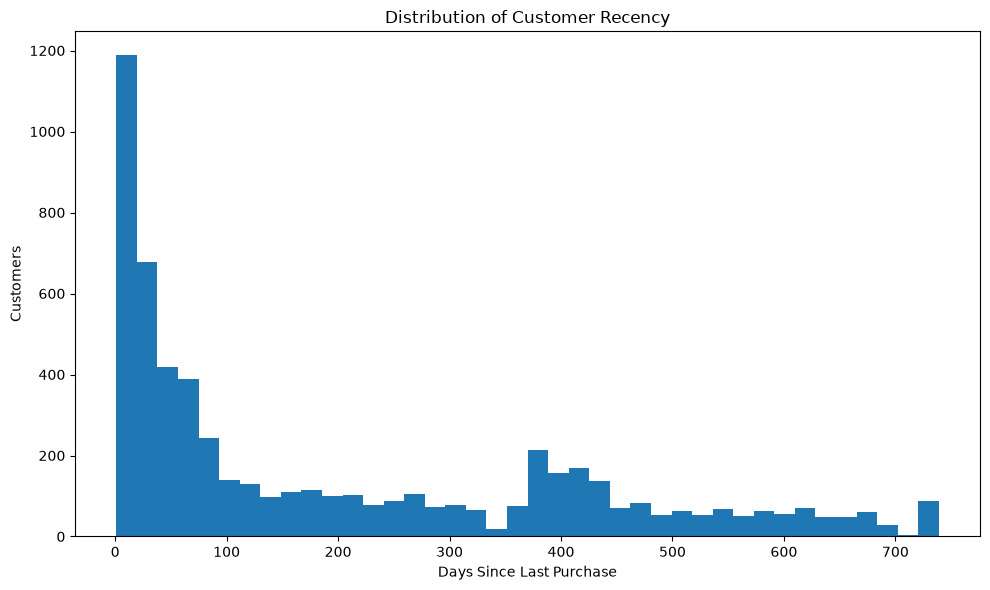

In [7]:
plt.figure(figsize=(10, 6))

plt.hist(
    rfm["recency"],
    bins=40,
)

plt.title("Distribution of Customer Recency")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Customers")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "rfm_recency_distribution.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()

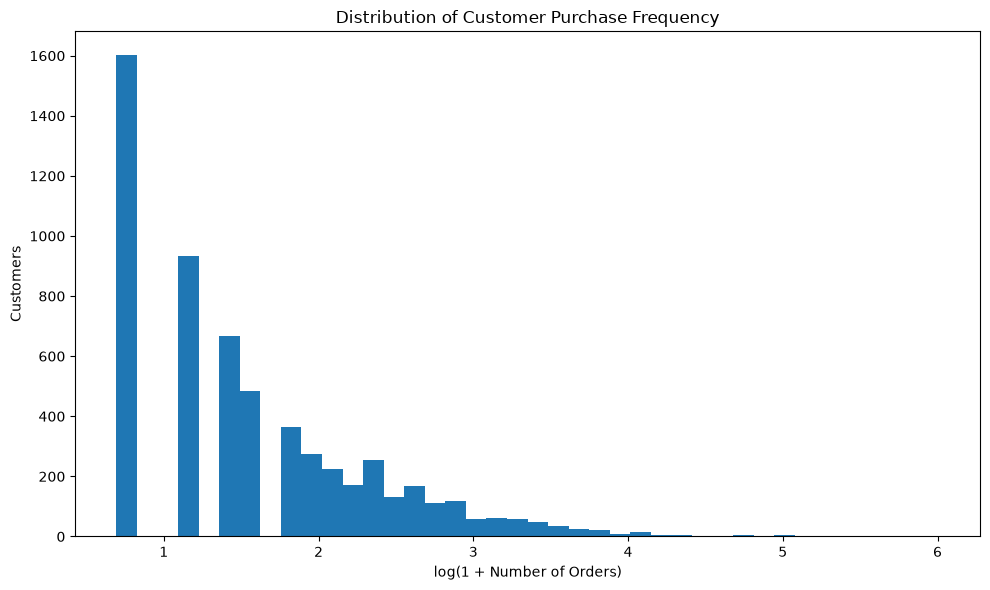

In [8]:
plt.figure(figsize=(10, 6))

plt.hist(
    np.log1p(rfm["frequency"]),
    bins=40,
)

plt.title("Distribution of Customer Purchase Frequency")
plt.xlabel("log(1 + Number of Orders)")
plt.ylabel("Customers")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "rfm_frequency_distribution.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()

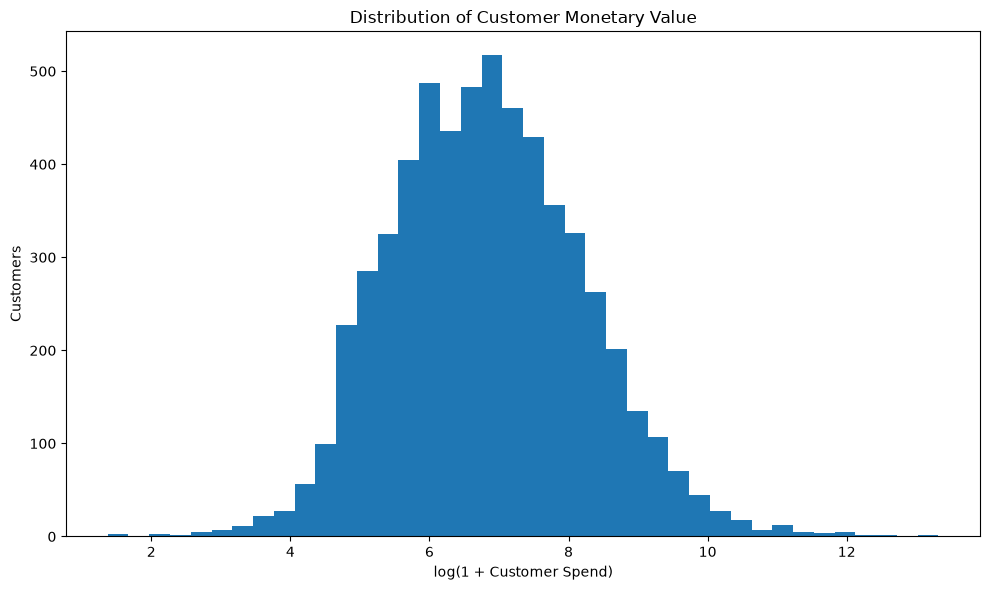

In [9]:
plt.figure(figsize=(10, 6))

plt.hist(
    np.log1p(rfm["monetary"]),
    bins=40,
)

plt.title("Distribution of Customer Monetary Value")
plt.xlabel("log(1 + Customer Spend)")
plt.ylabel("Customers")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "rfm_monetary_distribution.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()

In [10]:
def percentile_score(
    series: pd.Series,
    higher_is_better: bool = True,
) -> pd.Series:
    """Convert a metric into a 1-to-5 percentile score."""

    percentile_rank = series.rank(
        method="average",
        pct=True,
        ascending=higher_is_better,
    )

    scores = np.ceil(
        percentile_rank * 5
    ).clip(
        lower=1,
        upper=5,
    )

    return scores.astype("int8")

In [11]:
rfm["r_score"] = percentile_score(
    rfm["recency"],
    higher_is_better=False,
)

rfm["f_score"] = percentile_score(
    rfm["frequency"],
    higher_is_better=True,
)

rfm["m_score"] = percentile_score(
    rfm["monetary"],
    higher_is_better=True,
)


rfm["rfm_total_score"] = (
    rfm["r_score"]
    + rfm["f_score"]
    + rfm["m_score"]
)


rfm["rfm_code"] = (
    rfm["r_score"].astype(str)
    + rfm["f_score"].astype(str)
    + rfm["m_score"].astype(str)
)


display(
    rfm[
        [
            "customer_id",
            "recency",
            "frequency",
            "monetary",
            "r_score",
            "f_score",
            "m_score",
            "rfm_total_score",
            "rfm_code",
        ]
    ].head(20)
)

,customer_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_total_score,rfm_code
0,12346,326,12,"77,556.46",2,5,5,12,255
1,12347,2,9,"5,633.32",5,5,5,15,555
2,12348,75,5,"2,019.40",3,4,4,11,344
3,12349,19,4,"4,428.69",5,3,5,13,535
4,12350,310,1,334.40,2,1,2,5,212
5,12351,375,1,300.93,2,1,2,5,212
6,12352,36,10,"2,849.84",4,5,4,13,454
7,12353,204,2,406.76,2,2,2,6,222
8,12354,232,1,"1,079.40",2,1,3,6,213
9,12355,214,2,947.61,2,2,3,7,223


In [12]:
for score_column in [
    "r_score",
    "f_score",
    "m_score",
]:
    print(f"\n{score_column}")

    display(
        rfm[
            score_column
        ]
        .value_counts()
        .sort_index()
        .to_frame("customers")
    )


r_score


,customers
r_score,
1,1175
2,1177
3,1162
4,1176
5,1188



f_score


,customers
f_score,
1,1601
2,935
3,1151
4,1037
5,1154



m_score


,customers
m_score,
1,1175
2,1176
3,1175
4,1176
5,1176


In [13]:
r = rfm["r_score"]
f = rfm["f_score"]


conditions = [
    # Very valuable historically, but now inactive.
    (r <= 2) & (f >= 4),

    # Recently active and very frequent.
    (r >= 4) & (f >= 4),

    # Strong repeat customers.
    (r >= 3) & (f >= 3),

    # Recent customers showing repeat behavior.
    (r >= 4) & (f.isin([2, 3])),

    # Very recent first-time customers.
    (r == 5) & (f == 1),

    # Recent but still low-frequency.
    (r == 4) & (f == 1),

    # Moderate recency and frequency.
    (r == 3) & (f.isin([2, 3])),

    # Previously frequent, but becoming inactive.
    (r <= 2) & (f >= 3),

    # Low recent engagement and low frequency.
    (r.isin([2, 3])) & (f <= 2),

    # Old and infrequent customers.
    (r <= 2) & (f <= 2),
]


segments = [
    "Cannot Lose Them",
    "Champions",
    "Loyal Customers",
    "Potential Loyalists",
    "New Customers",
    "Promising",
    "Need Attention",
    "At Risk",
    "About to Sleep",
    "Hibernating",
]


rfm["segment"] = np.select(
    conditions,
    segments,
    default="Other",
)

In [14]:
rfm["value_tier"] = np.select(
    [
        rfm["m_score"] >= 4,
        rfm["m_score"] == 3,
        rfm["m_score"] <= 2,
    ],
    [
        "High Value",
        "Medium Value",
        "Low Value",
    ],
    default="Unknown",
)

In [15]:
business_actions = {
    "Champions": (
        "Reward with VIP benefits, early access, "
        "referral incentives, and premium experiences."
    ),

    "Loyal Customers": (
        "Strengthen loyalty through personalized offers, "
        "cross-selling, and loyalty rewards."
    ),

    "Potential Loyalists": (
        "Encourage the next purchase with personalized "
        "recommendations and targeted incentives."
    ),

    "New Customers": (
        "Focus on onboarding and driving the second purchase."
    ),

    "Promising": (
        "Use low-cost nurturing campaigns and product recommendations."
    ),

    "Need Attention": (
        "Use personalized re-engagement before activity declines further."
    ),

    "At Risk": (
        "Prioritize retention campaigns and investigate "
        "the reason for declining engagement."
    ),

    "Cannot Lose Them": (
        "High-priority retention intervention; consider direct outreach "
        "and strong personalized incentives."
    ),

    "About to Sleep": (
        "Trigger low-cost reactivation campaigns."
    ),

    "Hibernating": (
        "Use inexpensive win-back campaigns and avoid "
        "high acquisition-style spending."
    ),

    "Other": (
        "Monitor behavior and reassess after additional activity."
    ),
}


rfm["recommended_action"] = (
    rfm["segment"].map(
        business_actions
    )
)

In [16]:
segment_summary = (
    rfm.groupby(
        "segment",
        observed=True,
    )
    .agg(
        customers=("customer_id", "count"),
        revenue=("monetary", "sum"),
        average_recency=("recency", "mean"),
        average_frequency=("frequency", "mean"),
        average_monetary=("monetary", "mean"),
        median_monetary=("monetary", "median"),
        average_order_value=("average_order_value", "mean"),
    )
    .reset_index()
)


segment_summary["customer_share_pct"] = (
    segment_summary["customers"]
    / segment_summary["customers"].sum()
    * 100
)


segment_summary["revenue_share_pct"] = (
    segment_summary["revenue"]
    / segment_summary["revenue"].sum()
    * 100
)


segment_summary = segment_summary.sort_values(
    "revenue",
    ascending=False,
).reset_index(drop=True)


display(segment_summary)

,segment,customers,revenue,average_recency,average_frequency,average_monetary,median_monetary,average_order_value,customer_share_pct,revenue_share_pct
0,Champions,1423,"12,189,047.71",20.03,16.50,"8,565.74","3,625.88",417.05,24.21,68.92
1,Loyal Customers,1190,"2,561,370.57",77.39,5.69,"2,152.41","1,293.37",373.87,20.24,14.48
2,Cannot Lose Them,298,"1,056,759.03",339.55,8.60,"3,546.17","1,739.22",375.77,5.07,5.98
3,At Risk,431,"518,199.94",374.97,3.40,"1,202.32",885.71,358.77,7.33,2.93
4,Hibernating,954,"418,462.66",555.65,1.25,438.64,260.51,347.25,16.23,2.37
5,About to Sleep,913,"399,892.47",259.95,1.29,438.00,309.49,345.02,15.53,2.26
6,Potential Loyalists,261,"339,225.11",25.14,2.00,"1,299.71",547.07,649.86,4.44,1.92
7,Need Attention,169,"121,752.26",111.39,2.00,720.43,603.46,360.21,2.88,0.69
8,Promising,164,"54,716.41",38.89,1.00,333.64,224.52,333.64,2.79,0.31
9,New Customers,75,"26,034.48",11.13,1.00,347.13,269.96,347.13,1.28,0.15


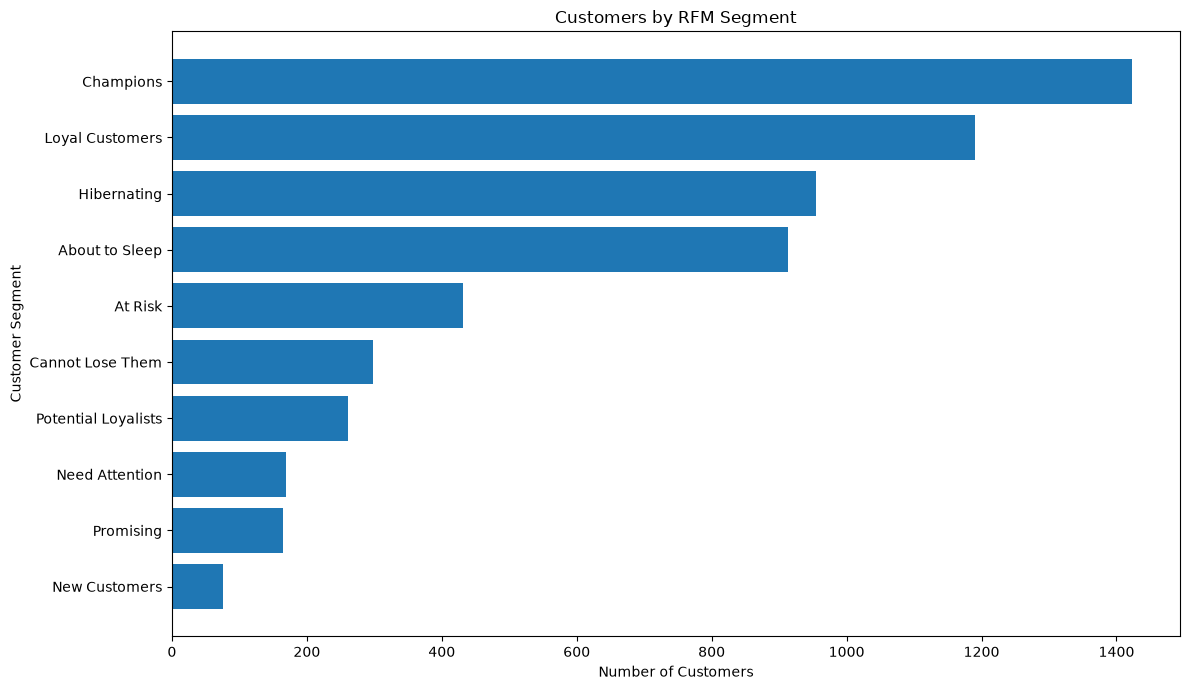

In [17]:
plot_data = (
    segment_summary
    .sort_values(
        "customers",
        ascending=True,
    )
)


plt.figure(figsize=(12, 7))

plt.barh(
    plot_data["segment"],
    plot_data["customers"],
)

plt.title("Customers by RFM Segment")
plt.xlabel("Number of Customers")
plt.ylabel("Customer Segment")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "rfm_customers_by_segment.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()

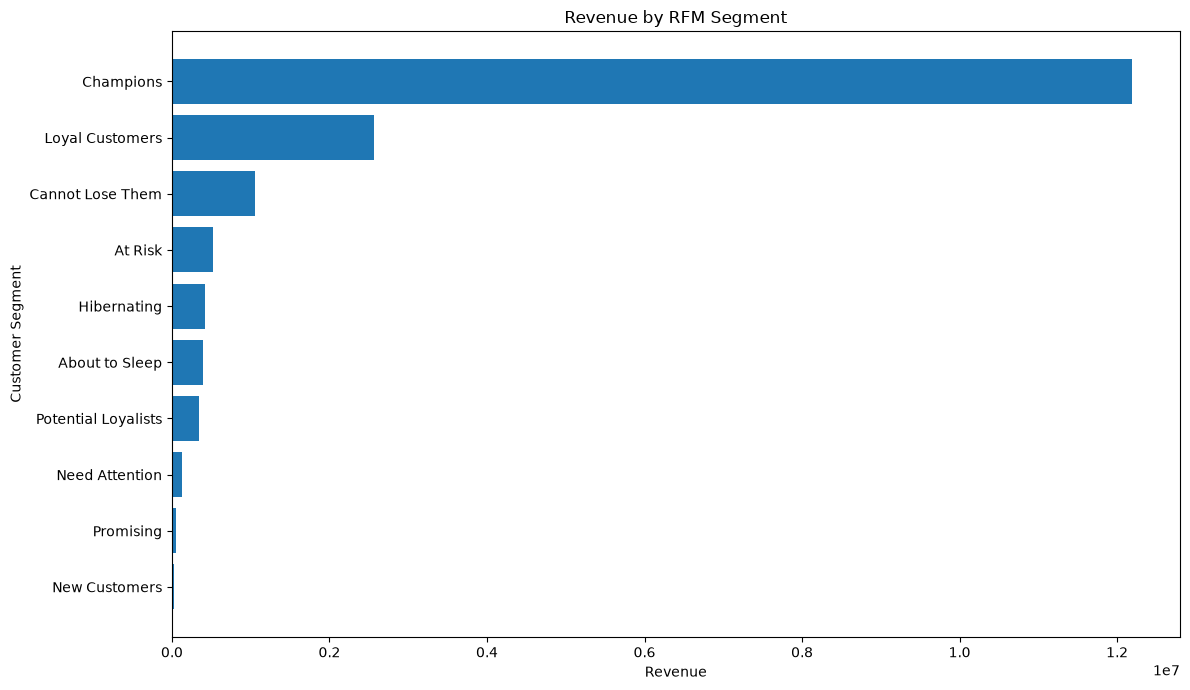

In [18]:
plot_data = (
    segment_summary
    .sort_values(
        "revenue",
        ascending=True,
    )
)


plt.figure(figsize=(12, 7))

plt.barh(
    plot_data["segment"],
    plot_data["revenue"],
)

plt.title("Revenue by RFM Segment")
plt.xlabel("Revenue")
plt.ylabel("Customer Segment")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "rfm_revenue_by_segment.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()

In [19]:
top_customers = (
    rfm[
        [
            "customer_id",
            "segment",
            "value_tier",
            "recency",
            "frequency",
            "monetary",
            "average_order_value",
            "r_score",
            "f_score",
            "m_score",
            "rfm_total_score",
        ]
    ]
    .sort_values(
        "monetary",
        ascending=False,
    )
    .head(20)
)


display(top_customers)

,customer_id,segment,value_tier,recency,frequency,monetary,average_order_value,r_score,f_score,m_score,rfm_total_score
5692,18102,Champions,High Value,1,149,"608,821.65","4,086.05",5,5,5,15
2277,14646,Champions,High Value,2,151,"528,602.52","3,500.68",5,5,5,15
1789,14156,Champions,High Value,10,157,"313,759.82","1,998.47",5,5,5,15
2538,14911,Champions,High Value,1,406,"295,832.39",728.65,5,5,5,15
5050,17450,Champions,High Value,8,53,"246,813.09","4,656.85",5,5,5,15
1331,13694,Champions,High Value,4,144,"196,482.81","1,364.46",5,5,5,15
5109,17511,Champions,High Value,3,62,"175,603.55","2,832.32",5,5,5,15
4061,16446,Potential Loyalists,High Value,1,2,"168,472.50","84,236.25",5,2,5,12
4295,16684,Champions,High Value,4,55,"147,142.77","2,675.32",5,5,5,15
68,12415,Champions,High Value,24,28,"144,458.37","5,159.23",4,5,5,14


In [20]:
high_value_at_risk = (
    rfm.loc[
        rfm["segment"].isin(
            [
                "At Risk",
                "Cannot Lose Them",
            ]
        )
        & (rfm["m_score"] >= 4)
    ]
    .sort_values(
        "monetary",
        ascending=False,
    )
)


print(
    f"High-value customers at risk: "
    f"{len(high_value_at_risk):,}"
)


display(
    high_value_at_risk[
        [
            "customer_id",
            "segment",
            "recency",
            "frequency",
            "monetary",
            "rfm_code",
            "recommended_action",
        ]
    ].head(30)
)

High-value customers at risk: 324


,customer_id,segment,recency,frequency,monetary,rfm_code,recommended_action
0,12346,Cannot Lose Them,326,12,"77,556.46",255,High-priority retention intervention; consider...
4364,16754,Cannot Lose Them,372,30,"67,502.47",255,High-priority retention intervention; consider...
5442,17850,Cannot Lose Them,372,189,"56,600.08",255,High-priority retention intervention; consider...
743,13093,Cannot Lose Them,276,56,"54,943.65",255,High-priority retention intervention; consider...
3371,15749,At Risk,235,3,"44,534.30",235,Prioritize retention campaigns and investigate...
1538,13902,Cannot Lose Them,632,5,"34,095.26",145,High-priority retention intervention; consider...
135,12482,Cannot Lose Them,576,29,"23,691.40",155,High-priority retention intervention; consider...
1698,14063,Cannot Lose Them,438,9,"22,710.20",155,High-priority retention intervention; consider...
3429,15808,Cannot Lose Them,306,22,"18,133.30",255,High-priority retention intervention; consider...
5048,17448,Cannot Lose Them,497,46,"14,523.67",155,High-priority retention intervention; consider...


In [21]:
rfm.to_parquet(
    OUTPUT_PATH,
    index=False,
)


rfm.to_csv(
    REPORTS_DIR / "rfm_customer_segments.csv",
    index=False,
)


segment_summary.to_csv(
    REPORTS_DIR / "rfm_segment_summary.csv",
    index=False,
)


high_value_at_risk.to_csv(
    REPORTS_DIR / "high_value_customers_at_risk.csv",
    index=False,
)


rfm_report = {
    "analysis_date": str(analysis_date),
    "customers": int(len(rfm)),
    "segments": int(rfm["segment"].nunique()),
    "high_value_customers": int(
        (rfm["m_score"] >= 4).sum()
    ),
    "high_value_customers_at_risk": int(
        len(high_value_at_risk)
    ),
    "total_customer_revenue": float(
        rfm["monetary"].sum()
    ),
}


(
    REPORTS_DIR / "rfm_summary.json"
).write_text(
    json.dumps(
        rfm_report,
        indent=2,
    ),
    encoding="utf-8",
)


print("RFM segmentation saved successfully.")
print(f"Customer segments: {OUTPUT_PATH}")

RFM segmentation saved successfully.
Customer segments: c:\Users\omary\Documents\VS Code\customer-intelligence-analytics\data\processed\rfm_customer_segments.parquet


In [22]:
assert len(rfm) == 5_878

assert rfm["customer_id"].is_unique

assert rfm[
    [
        "r_score",
        "f_score",
        "m_score",
    ]
].isin(
    [1, 2, 3, 4, 5]
).all().all()

assert rfm["segment"].notna().all()

assert rfm["recommended_action"].notna().all()

assert np.isclose(
    rfm["monetary"].sum(),
    customer_sales["line_amount"].sum(),
)


print("=" * 60)
print("RFM segmentation completed successfully")
print("=" * 60)
print(f"Customers segmented: {len(rfm):,}")
print(f"Segments created:    {rfm['segment'].nunique()}")
print(
    f"High-value at risk:  "
    f"{len(high_value_at_risk):,}"
)

RFM segmentation completed successfully
Customers segmented: 5,878
Segments created:    10
High-value at risk:  324


## RFM Business Interpretation

The RFM analysis reveals a highly concentrated customer base with clear
differences in customer value and engagement.

### Champions dominate customer revenue

The Champions segment contains 1,423 customers (24.21% of purchasing
customers) but generates approximately 68.92% of customer revenue.

These customers purchase very recently, buy frequently, and generate
substantially higher monetary value than other customer groups. Maintaining
their loyalty is therefore strategically important.

### Loyal Customers represent the second major source of value

Loyal Customers account for 1,190 customers and approximately 14.48% of
customer revenue. They purchase repeatedly and represent a strong opportunity
for loyalty programs, cross-selling, and personalized recommendations.

### Valuable inactive customers create a retention opportunity

The Cannot Lose Them segment contains 298 historically valuable customers.
Their average purchase frequency is high, but their average recency is
approximately 340 days.

These customers previously demonstrated strong purchasing behavior but have
become inactive, making them particularly important targets for retention and
reactivation campaigns.

The analysis also identifies 324 high-value customers belonging to the
At Risk or Cannot Lose Them segments. These customers should receive priority
in the later retention decision engine.

### Large inactive segments should not automatically receive expensive offers

Hibernating and About to Sleep customers represent a substantial proportion
of the customer base but contribute relatively little revenue.

This illustrates why retention decisions should combine churn risk with
customer value rather than targeting every inactive customer equally.

### New and promising customers require a different strategy

New Customers and Promising customers have low purchase frequency because
their relationships with the business are still developing.

For these customers, the objective should be to encourage a second purchase
and increase engagement rather than immediately applying traditional
retention campaigns.

### RFM provides an interpretable business baseline

RFM segmentation provides an intuitive and actionable description of customer
behavior. However, it relies on predefined business rules.

The next stage will therefore apply unsupervised machine learning to determine
whether natural customer groups can be discovered directly from behavioral
features and to compare those clusters with the RFM segments.